In [21]:
import numpy as np
import pylab
import matplotlib.pyplot as plt
%matplotlib notebook
import matplotlib.gridspec as gridspec
import os.path as op
import mne
from mne.datasets import sample
from mne.preprocessing import ICA
from mne.preprocessing import create_ecg_epochs, create_eog_epochs 
from solvenan2 import *
from run_coupled_ntf import *
from run_coupled_nmf import *
from scipy import signal
from spectro_analysis import *
from ValidationICA import * 
import seaborn

In [3]:
plt.close('all')

data_path = op.join(mne.datasets.sample.data_path(), 'MEG', 'sample')
raw = mne.io.read_raw_fif(op.join(data_path, 'sample_audvis_raw.fif'), preload=True)
events = mne.read_events(op.join(data_path, 'sample_audvis_raw-eve.fif'))


Opening raw data file /Users/renatobottermaiolopesrodrigues/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
Current compensation grade : 0
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Adding average EEG reference projection.
1 projection items deactivated
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


In [4]:
#Hight-Pass Filter
raw.filter(l_freq=1, h_freq=None)

High-pass filtering at 1 Hz


<Raw  |  sample_audvis_raw.fif, n_channels x n_times : 376 x 166800 (277.7 sec)>

In [5]:
eeg_only = raw.copy().pick_types(meg=False, eeg=True)
eog_only = raw.copy().pick_types(meg=False, eeg=False, eog=True)
eeg_only_NMF = eeg_only.copy().pick_types(meg=False, eeg=True)
epochs_before = mne.Epochs(eeg_only, events)
evoked_before = epochs_before.average()

320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


In [6]:
sfreq = eeg_only.info['sfreq']
Fs=sfreq
Tau = 0.7
hopsize=1/8
win='h'
Nw=np.round(Tau * Fs)
R = np.round(hopsize * Nw) 
N = eeg_only._data.shape[1]
Nt = np.array([np.fix((N-Nw)/R)])

In [7]:
solvenan2(eog_only._data)

V1,Ph1,tr1,f1 = spectrogramme(eog_only._data[0,:],Fs,Tau,hopsize, win)
v1 = V1/np.max(np.absolute(V1))
n1=np.max(np.abs(V1))

In [25]:
sensors=np.array([2, 20])

N=len(sensors)
norm2_NMF_1=np.zeros([1,N])
cm_NMF_1=np.zeros([1,N])
mi_NMF_1=np.zeros([1,N])
evoked_after_NMF_1=np.zeros(evoked_before.data.shape)


In [26]:
k1=np.array([2, 4, 8, 16])
k2=np.array([4, 8, 16, 32])

nan_counter=np.zeros([len(k1), len(sensors)])
niniti_counter=np.zeros([len(k1), len(sensors)])


<IPython.core.display.Javascript object>


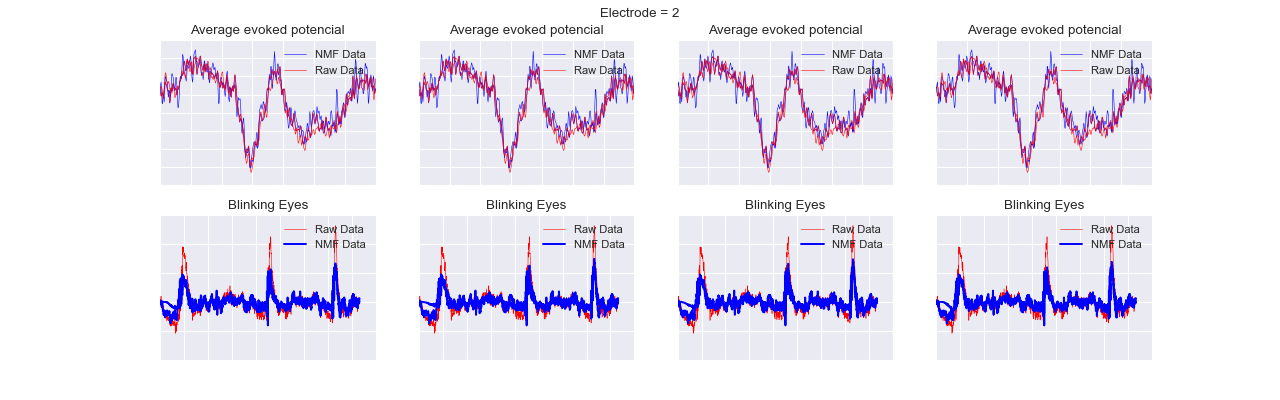

100%|██████████| 9/9 [00:03<00:00,  2.44it/s]
/Users/renatobottermaiolopesrodrigues/Desktop/Backup/spectrogramacerto.py:97: ComplexWarning: Casting complex values to real discards the imaginary part
  y_aux[:,0] = Xtilde_inv*window


320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


100%|██████████| 9/9 [00:04<00:00,  2.01it/s]


320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


100%|██████████| 9/9 [00:04<00:00,  2.22it/s]


320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


100%|██████████| 9/9 [00:04<00:00,  2.17it/s]


320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


<IPython.core.display.Javascript object>


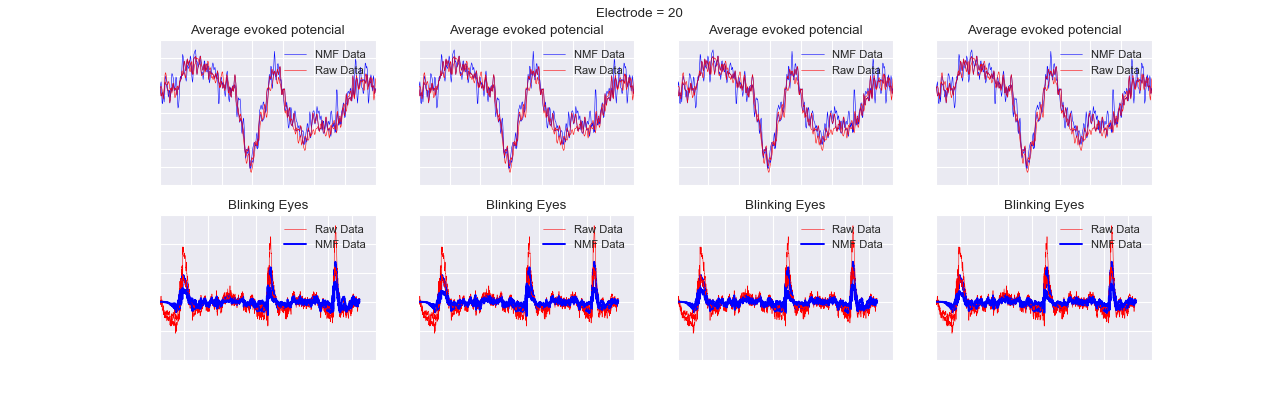

100%|██████████| 9/9 [00:05<00:00,  1.70it/s]


320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


100%|██████████| 9/9 [00:05<00:00,  1.48it/s]


320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


100%|██████████| 9/9 [00:07<00:00,  1.43it/s]


320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


100%|██████████| 9/9 [00:05<00:00,  1.55it/s]


320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


In [29]:
for m in range(0, N): 
    fig = plt.figure(figsize=(16,5))

    for i in range(0, len(k1)):

        K1=k1[i]
        K2=k2[i]        
        
        V2_1, Ph2_1, tr2_1, f2_1 = spectrogramme(eeg_only._data[sensors[m],:],Fs,Tau,hopsize, win)
        v2_1 = V2_1/np.max(np.absolute(V2_1))
        n2_1=np.max(np.abs(V2_1))
        
        w1_1, h1_1, w2_1, h2_1, nan_counter[i, m], niniti_counter[i, m]=nmf_coupled(v1,v2_1, K1=k1[i],K2=k2[i], ninit=2, niter=10) 
        
        Vhat1_1=rebuild (w1_1,h1_1)
        Vhat2_1=rebuild (w2_1,h2_1)
        
        Vclean_T_1=rebuild(w2_1[:,0:K1],h2_1[:,0:K1])
        Vres_T_1=rebuild(w2_1[:,K1:w2_1.shape[1]],h2_1[:,K1:h2_1.shape[1]])
        
        V_clean_1=n2_1*v2_1*(np.power(Vclean_T_1,2)/(np.power(Vclean_T_1,2) + np.power(Vres_T_1,2)))
        V_artefacts_1=n1*v2_1*(np.power(Vres_T_1,2)/(np.power(Vclean_T_1,2) + np.power(Vres_T_1,2)))
        
        xclean_1=spectrogramme_inv(V_clean_1,Ph2_1,Fs,Tau,hopsize,win)[:,0]
        xexg_1=spectrogramme_inv(V_artefacts_1,Ph1,Fs,Tau,hopsize,win)[:,0]
        
        eeg_only_NMF._data[sensors[m],:]=xclean_1[0:eeg_only_NMF._data.shape[1]]
    
        epochs_after_NMF_1 = mne.Epochs(eeg_only_NMF, events)    
        evoked_after_NMF_1 = epochs_after_NMF_1.average()
        
        
        ax1=plt.subplot(2,4,i+1)
        
        for k in range(0, N):   
            if k==0:
                plt.plot(evoked_after_NMF_1.times,evoked_after_NMF_1.data[k,:], color='b', linewidth=0.5, label ='NMF Data')
                plt.plot(evoked_before.times,evoked_before.data[sensors[k],:], color='r', linewidth=0.5, label='Raw Data')
            else:
                plt.plot(evoked_after_NMF_1.times,evoked_after_NMF_1.data[k,:], color='b', linewidth=0.5)
                plt.plot(evoked_before.times,evoked_before.data[k,:], color='r', linewidth=0.5)
        
        plt.legend()
        ax1.set_xticklabels([])
        ax1.set_yticklabels([])

        plt.title('Average evoked potencial')
        
        ax2=plt.subplot(2,4,i+4+1)
        
        tmax=2500
        tmax_a=2500
        
        for k in range(0, len(sensors)):
            if k==0:
                plt.plot(eeg_only_NMF._times[0:tmax],np.transpose (eeg_only._data)[0:tmax, sensors[k]],  color='r', linewidth=0.5, label='Raw Data')
                plt.plot(eeg_only_NMF._times[0:tmax],eeg_only_NMF._data[sensors[k], 0:tmax], color='b', label='NMF Data')
            else:
                plt.plot(eeg_only_NMF._times[0:tmax],np.transpose (eeg_only._data)[0:tmax, sensors[k]],  color='r', linewidth=0.5)
                plt.plot(eeg_only_NMF._times[0:tmax],eeg_only_NMF._data[sensors[k], 0:tmax], color='b')
        ax2.set_xticklabels([])
        ax2.set_yticklabels([])
        plt.legend()
        plt.title('Blinking Eyes')
    plt.suptitle('Analysis for Electrode %s'%(sensors[m]))
    pylab.savefig('%s.png'%(i+11))

In [ ]:
pylab.savefig('1_nmf.png')

<IPython.core.display.Javascript object>


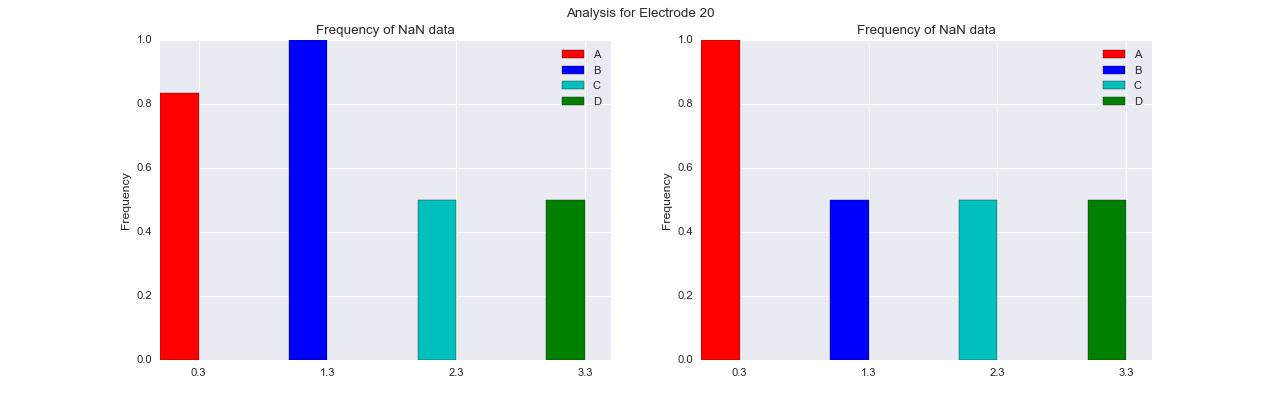

In [34]:
fig = plt.figure(figsize=(16,5))

for i in range(0, len(sensors)):
    
    plt.subplot(1,2,i+1)
    frequency_Nan = (nan_counter/niniti_counter)
    ind = np.arange(4)  # the x locations for the groups
    width = 0.3       # the width of the bars
    
    
    plt.bar(ind[0], frequency_Nan[0][i], width, color='r', label='A')
    plt.bar(ind[1], frequency_Nan[1][i], width, color='b', label='B')
    plt.bar(ind[2], frequency_Nan[2][i], width, color='c', label='C')
    plt.bar(ind[3], frequency_Nan[3][i], width, color='g', label='D')
    
    plt.legend()
    # add some text for labels, title and axes ticks
    plt.ylabel('Frequency')
    plt.title('Frequency of NaN data')
    plt.xticks(ind + width)
    plt.show()
    plt.suptitle('Analysis for Electrode %s'%(sensors[i]))

In [28]:
pylab.savefig('2_nmf.png')

In [31]:
frequency_Nan

array([[ 0.83333333,  1.        ],
       [ 1.        ,  0.5       ],
       [ 0.5       ,  0.5       ],
       [ 0.5       ,  0.5       ]])